In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from scipy.optimize import curve_fit

from astropy.cosmology import Planck18, FlatLambdaCDM
import astropy.units as u

cosmo = Planck18
fibre_diam_arcsec = 1.5

plt.rcParams.update({'figure.dpi': 110, 'font.size': 11,
                     'axes.grid': True, 'grid.alpha': 0.25})

# --- Physical constants / unit system --------------------------------------
G  = 4.30091e-6     # gravitational constant [kpc (km/s)^2 / Msun]
MU = 2.3e9          # mass unit used in Table 1 [Msun]

# --- Table 1: mass & length parameters for the fiducial Sa galaxy ----------
# masses in units of 2.3e9 Msun, lengths in kpc
P = dict(
    Mgas=4.0,   agas=5.0,  hgas=0.2,     # gaseous disc  (Miyamoto-Nagai)
    Mdisc=40.0, adisc=4.0, hdisc=0.5,    # stellar disc  (Miyamoto-Nagai)
    Mbulge=10.0, bbulge=2.0,             # stellar bulge (Plummer), fiducial b=2
    MDM=50.0,    bDM=10.0,               # dark-matter halo (Plummer)
)

# --- DESI observation parameters -------------------------------------------
INSTR  = 30.0    # mean DESI instrumental broadening [km/s]
DV_BIN = 30.0    # DESI spectral bin width delta_v [km/s]

# Three representative redshifts -> 1.5'' fibre physical diameter (Sect. 2.2)
REDSHIFTS = {}
for z in [0.10, 0.20, 0.30, 0.40]:
    kpc_per_arcmin = cosmo.kpc_proper_per_arcmin(z)
    diam_kpc = fibre_diam_arcsec / 60 * kpc_per_arcmin
    REDSHIFTS[z] = diam_kpc.value # z : fibre diameter [kpc]
print("Fibre diameters [kpc]:", REDSHIFTS)




Fibre diameters [kpc]: {0.1: np.float64(2.8597332033033473), 0.2: np.float64(5.112226334063765), 0.3: np.float64(6.895766043329738), 0.4: np.float64(8.311760480913822)}


## 2. Rotation curve


$$V(R) = V_{rot}\,tanh(\frac{R}{R_{turn}})$$


In [37]:
def vrot_curve(R, V_rot=250, R_turn=1.5):
    '''Rotational velocity [km/s].'''
    return V_rot * np.tanh(R / R_turn) * np.exp(-(R - R_turn) / 30)  # exponential decay at large R

R = np.linspace(1e-3, 20, 600)
vc = vrot_curve(R)
print(f"Peak rotation velocity: {vc.max():.0f} km/s at R = {R[np.argmax(vc)]:.1f} kpc")


Peak rotation velocity: 230 km/s at R = 3.3 kpc


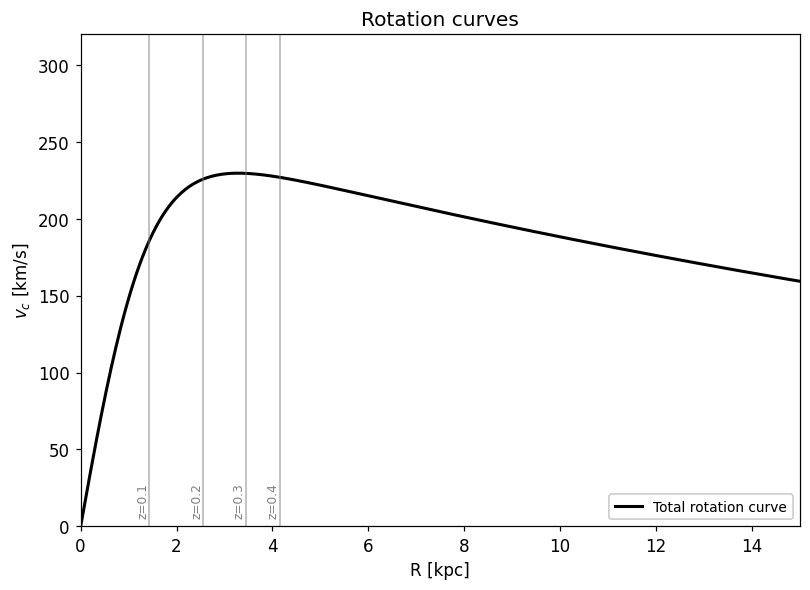

In [38]:
fig, ax = plt.subplots(figsize=(7.5, 5.5))
R = np.linspace(1e-3, 20, 600)


ax.plot(R, vc, 'k-', lw=2, label='Total rotation curve')

# fibre radii (vertical grey lines)
for z, d in REDSHIFTS.items():
    ax.axvline(d/2, color='grey', lw=1, alpha=0.6)
    ax.text(d/2, 5, f'z={z}', rotation=90, va='bottom', ha='right',
            fontsize=8, color='grey')

ax.set_xlabel('R [kpc]'); ax.set_ylabel(r'$v_c$ [km/s]')
ax.set_xlim(0, 15); ax.set_ylim(0, 320)
leg1 = ax.legend(loc='lower right', fontsize=9, framealpha=0.9)
ax.add_artist(leg1)
ax.set_title('Rotation curves')
plt.grid()
plt.tight_layout(); plt.show()


## 4. Gas surface density and the LOS-velocity spectrum

The gas disc surface density $\Sigma_{\rm gas}(R)=\int \rho_{\rm gas}(R,z)\,dz$ is
obtained by integrating the Miyamoto–Nagai density (Eq. 1) over $z$.

The LOS velocity is $V = V_{\rm rot}\cos\phi\sin i$ (Eq. 5). Following
Wiklind et al. (1997, Eq. 6), the gas is distributed over azimuth in each ring;
integrating the disc plane and keeping only material **inside the circular fibre**
(the fibre foreshortens the minor axis by $\cos i$) yields the LOS-velocity
spectrum. This grid integration handles a finite fibre size correctly (Eq. 6 is
only approximate when $R_{\max}$ is smaller than the disc).

In [39]:
def rho_gas(R, z, M, a, h):
    '''Miyamoto-Nagai volume density (Eq. 1).'''
    M = M * MU
    zh = np.sqrt(z**2 + h**2)
    num = a * R**2 + (a + 3*zh) * (a + zh)**2
    den = (R**2 + (a + zh)**2)**2.5 * zh**3
    return h**2 * M / (4*np.pi) * num / den

_ZZ = np.linspace(-4, 4, 241)
def sigma_gas(Rv, M, a, h):
    '''Surface density Sigma(R) by integrating rho over z.'''
    return np.array([np.trapezoid(rho_gas(r, _ZZ, M, a, h), _ZZ) for r in np.atleast_1d(Rv)])

def los_spectrum(i_deg, fibre_diam, p=P, agas=None, bbulge=None,
                 nR=500, nphi=1440, vmax=650, nv=261, Rdisc=30.0):
    '''Synthetic LOS gas-velocity spectrum within a circular fibre.'''
    agas = p['agas'] if agas is None else agas
    i  = np.radians(i_deg)
    Rf = fibre_diam / 2.0
    Rv = np.linspace(0.02, Rdisc, nR)
    Sg = sigma_gas(Rv, p['Mgas'], agas, p['hgas'])
    vc = vrot_curve(Rv)
    phi = np.linspace(0, 2*np.pi, nphi, endpoint=False)
    cphi, sphi = np.cos(phi), np.sin(phi)
    vgrid = np.linspace(-vmax, vmax, nv)
    hist = np.zeros(nv - 1)
    dR, dphi = Rv[1]-Rv[0], phi[1]-phi[0]
    for k, r in enumerate(Rv):
        x = r * cphi                    # sky x (major axis)
        y = r * sphi * np.cos(i)        # sky y (minor axis, foreshortened)
        inside = (x**2 + y**2) <= Rf**2
        if not inside.any():
            continue
        V = vc[k] * cphi * np.sin(i)    # Eq. 5
        w = Sg[k] * r * dR * dphi
        h, _ = np.histogram(V[inside], bins=vgrid,
                            weights=np.full(inside.sum(), w))
        hist += h
    vcen = 0.5 * (vgrid[:-1] + vgrid[1:])
    return vcen, hist


## 5. Double-peak detection (Sect. 2.3)

We convolve the LOS spectrum with the DESI instrumental broadening
($\sigma = 30$ km/s), rebin to the DESI resolution ($\delta v = 30$ km/s), and fit
single, double, and triple Gaussians with `scipy.optimize.curve_fit`. A DP is
flagged when **all three** criteria of the paper hold:

1. $\chi^2_\nu(\mathrm{single}) > \chi^2_\nu(\mathrm{double})$
2. $1/3 < A_1/A_2 < 3$
3. $\Delta v_{\rm DP} = |\mu_1-\mu_2| > 3\,\delta v = 207$ km/s

(No F-test is used because the synthetic spectra are noiseless.)

**Triple-peak (TP) extension**: the same logic is applied to a third component,
comparing the double- vs. triple-Gaussian fit and requiring both adjacent-peak
amplitude ratios and both adjacent-peak separations to satisfy criteria 2–3.
This axisymmetric model isn't expected to produce three peaks, but the machinery
is reused later for bar/merger kinematics.

In [40]:
# ---- Gaussian models + scipy.optimize.curve_fit -----------------------

def gauss(x, A, mu, s):   return A*np.exp(-0.5*((x-mu)/s)**2)
def gauss_j(x, A, mu, s):
    e = np.exp(-0.5*((x-mu)/s)**2)
    return np.stack([e, A*e*(x-mu)/s**2, A*e*(x-mu)**2/s**3], axis=1)

def dgauss(x, A1,m1,s1, A2,m2,s2):  return gauss(x,A1,m1,s1)+gauss(x,A2,m2,s2)
def dgauss_j(x, A1,m1,s1, A2,m2,s2):
    return np.concatenate([gauss_j(x,A1,m1,s1), gauss_j(x,A2,m2,s2)], axis=1)

def tgauss(x, A1,m1,s1, A2,m2,s2, A3,m3,s3):
    return gauss(x,A1,m1,s1) + gauss(x,A2,m2,s2) + gauss(x,A3,m3,s3)
def tgauss_j(x, A1,m1,s1, A2,m2,s2, A3,m3,s3):
    return np.concatenate([gauss_j(x,A1,m1,s1), gauss_j(x,A2,m2,s2),
                           gauss_j(x,A3,m3,s3)], axis=1)

def _fit(f, jac, p0, x, y):
    '''curve_fit with an analytic Jacobian and amplitudes A_i >= 0;
    falls back to p0 if it fails to converge.'''
    n = len(p0)
    lo = [0 if i % 3 == 0 else -np.inf for i in range(n)]  # A, mu, s per component
    hi = [np.inf] * n
    try:
        popt, _ = curve_fit(f, x, y, p0=p0, jac=jac, bounds=(lo, hi), maxfev=20000)
    except RuntimeError:
        popt = np.array(p0, float)
    return popt

def convolve_and_bin(vcen, spec):
    '''Convolve with 61 km/s Gaussian, rebin to 30 km/s DESI resolution.'''
    dv = vcen[1] - vcen[0]
    kx = np.arange(-4*INSTR, 4*INSTR + dv, dv)
    ker = np.exp(-0.5*(kx/INSTR)**2); ker /= ker.sum()
    smooth = np.convolve(spec, ker, mode='same')
    edges = np.arange(vcen[0]-DV_BIN/2, vcen[-1]+DV_BIN, DV_BIN)
    idx = np.clip(np.digitize(vcen, edges)-1, 0, len(edges)-2)
    binned = np.zeros(len(edges)-1); cnt = np.zeros_like(binned)
    np.add.at(binned, idx, smooth); np.add.at(cnt, idx, 1)
    binned = np.divide(binned, cnt, out=np.zeros_like(binned), where=cnt>0)
    return 0.5*(edges[:-1]+edges[1:]), binned, vcen, smooth

def fit_dp(bc, b):
    '''Fit single/double/triple Gaussians and apply the DP + triple-peak criteria.'''
    if b.max() <= 0:
        return None
    A0, mu0 = b.max(), bc[np.argmax(b)]
    spread = max(np.sqrt(np.sum(b*(bc-mu0)**2)/np.sum(b)), 40)

    single = _fit(gauss, gauss_j, [A0, mu0, spread], bc, b)

    p0_d = [A0*0.8, mu0-0.7*spread, 0.6*spread, A0*0.8, mu0+0.7*spread, 0.6*spread]
    double = _fit(dgauss, dgauss_j, p0_d, bc, b)

    p0_t = [A0*0.7, mu0-spread, 0.5*spread, A0*0.9, mu0, 0.5*spread,
            A0*0.7, mu0+spread, 0.5*spread]
    triple = _fit(tgauss, tgauss_j, p0_t, bc, b)

    ndof_s = max(len(bc)-3, 1); ndof_d = max(len(bc)-6, 1); ndof_t = max(len(bc)-9, 1)
    chi_s = np.sum((b-gauss(bc,*single))**2) / ndof_s
    chi_d = np.sum((b-dgauss(bc,*double))**2) / ndof_d
    chi_t = np.sum((b-tgauss(bc,*triple))**2) / ndof_t

    A1,m1,s1,A2,m2,s2 = double
    dv = abs(m1-m2); ratio = A1/A2 if A2 != 0 else np.inf
    is_dp = (chi_s > chi_d) and (1/3 < ratio < 3) and (dv > 3*DV_BIN)

    # sort the three triple-fit components by position so 1,2,3 read left-to-right
    comps = sorted([triple[0:3], triple[3:6], triple[6:9]], key=lambda c: c[1])
    (A1t,m1t,s1t), (A2t,m2t,s2t), (A3t,m3t,s3t) = comps
    dv12, dv23 = abs(m2t-m1t), abs(m3t-m2t)
    r12 = A1t/A2t if A2t != 0 else np.inf
    r23 = A2t/A3t if A3t != 0 else np.inf
    is_tp = (chi_d > chi_t) and (1/3 < r12 < 3) and (1/3 < r23 < 3) \
            and (dv12 > 3*DV_BIN) and (dv23 > 3*DV_BIN)

    return dict(single=single, double=double, triple=np.concatenate(comps),
                chi_s=chi_s, chi_d=chi_d, chi_t=chi_t,
                dv=dv, ratio=ratio, is_dp=bool(is_dp),
                dv12=dv12, dv23=dv23, r12=r12, r23=r23, is_tp=bool(is_tp))

# quick check against the paper's stated result (+ triple-peak flag, expected False here)
for z, d in REDSHIFTS.items():
    v, s = los_spectrum(90, d)
    r = fit_dp(*convolve_and_bin(v, s)[:2])
    print(f"i=90, z={z}: DP={r['is_dp']}  dv={r['dv']:.0f} km/s  "
          f"TP={r['is_tp']}  (dv12={r['dv12']:.0f}, dv23={r['dv23']:.0f})")

i=90, z=0.1: DP=False  dv=0 km/s  TP=False  (dv12=108, dv23=108)
i=90, z=0.2: DP=False  dv=0 km/s  TP=False  (dv12=159, dv23=159)
i=90, z=0.3: DP=False  dv=122 km/s  TP=True  (dv12=182, dv23=182)
i=90, z=0.4: DP=False  dv=202 km/s  TP=True  (dv12=189, dv23=189)


## 6. Figure 3 — Gas disc surface density with iso-velocity contours

2D projection of the Miyamoto–Nagai gas surface density at $i=30°$ and $i=60°$,
each rotated by a position angle of $20°$. Black iso-velocity contours are spaced
by 30 km/s (0 km/s on the minor axis). Orange/green circles mark the 3″ fibre at
$z=0.05$ (3 kpc) and $z=0.17$ (10 kpc). More inclined discs have a steeper
projected velocity gradient.

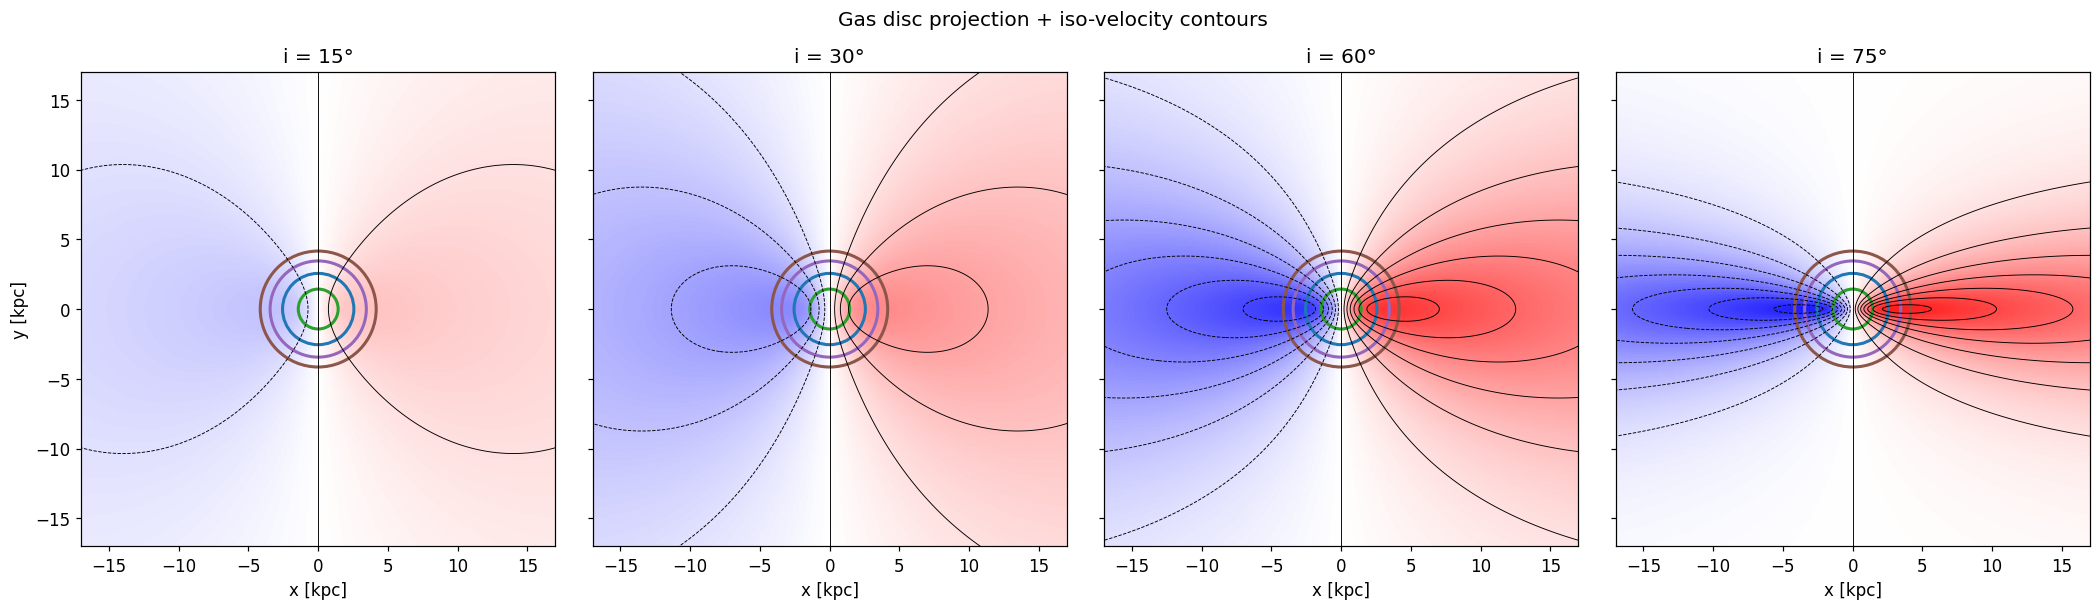

In [ ]:
def projected_maps(i_deg, pa_deg=0.0, extent=22, n=400):
    '''Return sky-plane surface density and LOS velocity grids.'''
    i, pa = np.radians(i_deg), np.radians(pa_deg)
    xs = np.linspace(-extent, extent, n)
    X, Y = np.meshgrid(xs, xs)
    # undo PA rotation
    Xr =  X*np.cos(pa) + Y*np.sin(pa)
    Yr = -X*np.sin(pa) + Y*np.cos(pa)
    # deproject minor axis
    xd = Xr
    yd = Yr / np.cos(i)
    Rd = np.sqrt(xd**2 + yd**2)
    Sig = sigma_gas(Rd.ravel(), P['Mgas'], P['agas'], P['hgas']).reshape(Rd.shape)
    phi = np.arctan2(yd, xd)
    Vlos = vrot_curve(Rd) * np.cos(phi) * np.sin(i)
    return X, Y, Sig, Vlos

incls = [15, 30, 60, 75]
fig, axes = plt.subplots(1, len(incls), figsize=(6*len(incls), 5.6), sharey=True)
plt.subplots_adjust(wspace=0.0, hspace=0.0)
for ax, i_deg in zip(axes, incls):
    X, Y, Sig, V = projected_maps(i_deg)
    # im = ax.pcolormesh(X, Y, Sig/Sig.max() * V, cmap='coolwarm', shading='auto')
    im = ax.pcolormesh(X, Y, V, cmap='bwr', shading='auto', vmin=-250, vmax=250)
    lv = np.arange(-300, 301, 30)
    ax.contour(X, Y, V, levels=lv, colors='k', linewidths=0.6)
    for z, d, col in [(0.10, REDSHIFTS[0.10], 'tab:green'), (0.20, REDSHIFTS[0.20], 'tab:blue'), (0.30, REDSHIFTS[0.30], 'tab:purple'), (0.40, REDSHIFTS[0.40], 'tab:brown')]:
        ax.add_patch(Circle((0,0), d/2, fill=False, color=col, lw=2))
    ax.set_aspect('equal'); ax.set_xlim(-17,17); ax.set_ylim(-17,17)
    ax.set_xlabel('x [kpc]')
    ax.set_title(f'i = {i_deg}°'); ax.grid(False)
    
axes[0].set_ylabel('y [kpc]')
# axes[len(axes)-1].colorbar(im, ax=axes[len(axes)-1], fraction=0.046, label=r'$\Sigma/\Sigma_{max}$')
# fig.suptitle('Gas disc projection + iso-velocity contours')
# plt.tight_layout()
plt.show()


## 7. Figure 4 — Emission-line profiles at different inclinations

Rows: inclinations $i = 20°, 40°, 60°, 90°$. Columns:
(1) raw LOS-velocity spectrum (Eq. 6), (2) after convolution with the DESI
instrumental broadening, (3) binned to the DESI resolution with the single
(yellow) and double-Gaussian (black; blue/red components) fits. Orange = small
fibre ($z=0.05$, 3 kpc); green = large fibre ($z=0.17$, 10 kpc). A DP is detected
only for the 10 kpc fibre at $i=90°$.

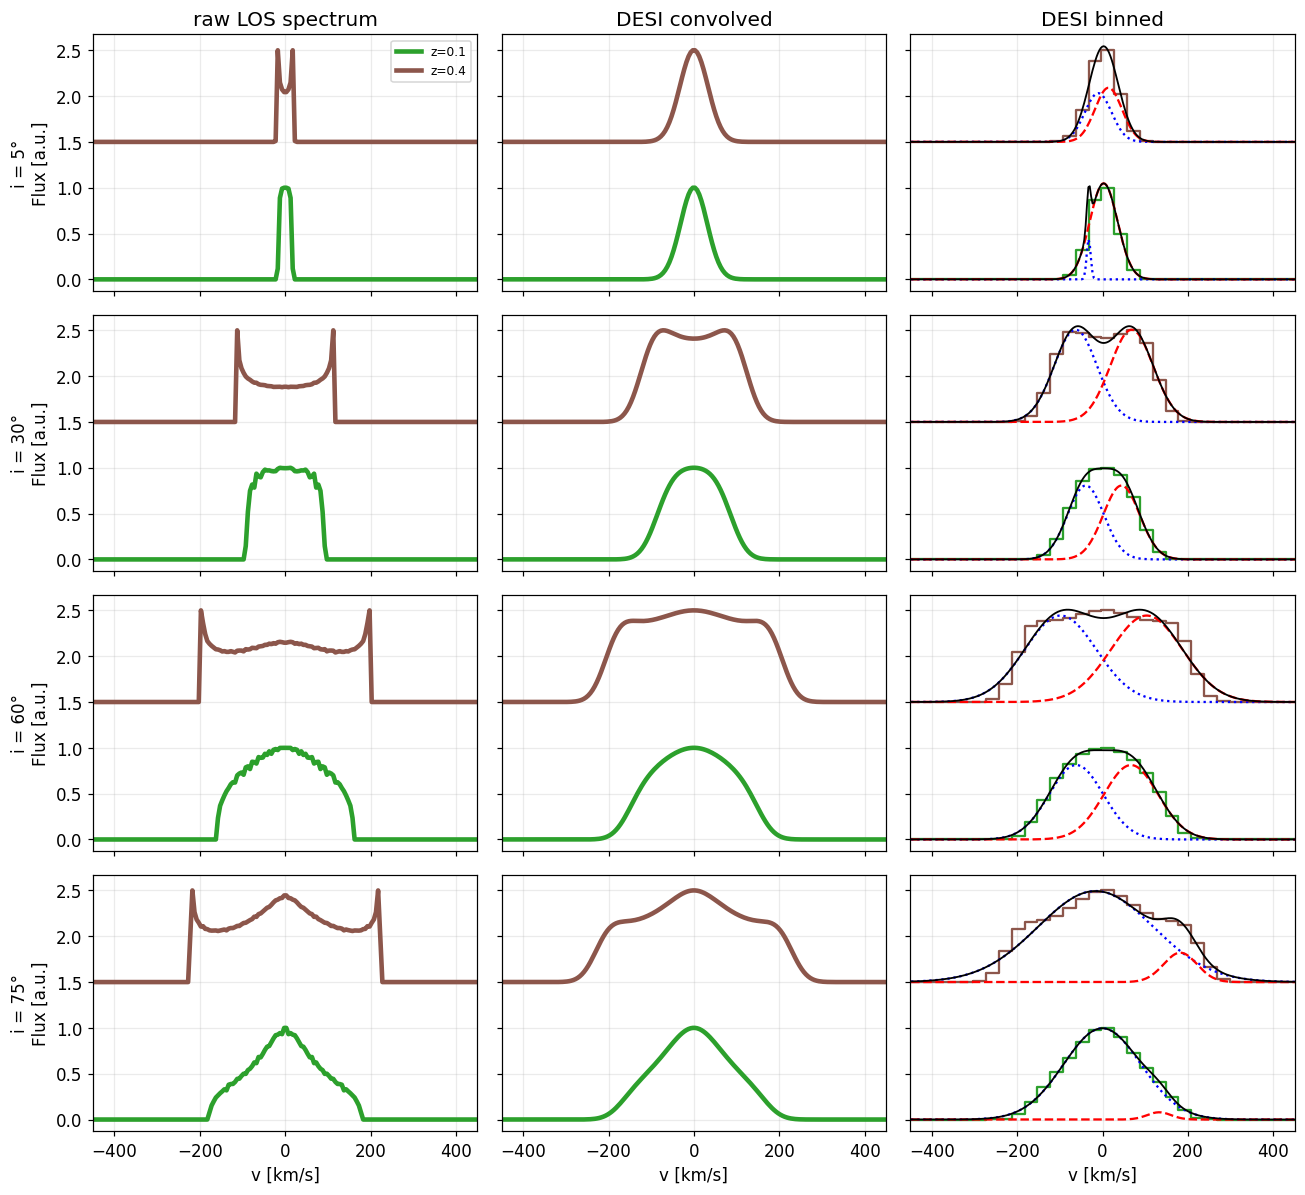

In [42]:
incls = [5, 30, 60, 75]
fibres = [
  (0.10, REDSHIFTS[0.10], 'tab:green'), 
  # (0.20, REDSHIFTS[0.20], 'tab:blue'), 
  # (0.30, REDSHIFTS[0.30], 'tab:purple'), 
  (0.40, REDSHIFTS[0.40], 'tab:brown')
]
fig, axes = plt.subplots(len(incls), 3, figsize=(3*len(incls), 11), sharex=True, sharey=True)

for row, i_deg in enumerate(incls):
    for k, (z, d, col) in enumerate(fibres):
        vcen, spec = los_spectrum(i_deg, d)
        bc, binned, vs, smooth = convolve_and_bin(vcen, spec)
        norm = spec.max() if spec.max() > 0 else 1
        # col 1: raw
        axes[row,0].plot(vcen, spec/norm + 1.5*k, color=col, label=f'z={z}', lw=3)
        # col 2: convolved
        axes[row,1].plot(vs, smooth/ (smooth.max() or 1) + 1.5*k, color=col, lw=3)
        # col 3: binned + fits (draw for the large fibre, the DP-relevant one)
        bn = binned/ (binned.max() or 1)
        axes[row,2].step(bc, bn + 1.5*k, where='mid', color=col, lw=1.5)
        r = fit_dp(bc, binned)
        xf = np.linspace(bc[0], bc[-1], 400)
        sc = (binned.max() or 1)
        # axes[row,2].plot(xf, gauss(xf,*r['single'])/sc, 'y-', lw=1.5)
        
        A1,m1,s1,A2,m2,s2 = r['double']
        axes[row,2].plot(xf, gauss(xf,A1,m1,s1)/sc + 1.5*k, 'b:', lw=1.5)
        axes[row,2].plot(xf, gauss(xf,A2,m2,s2)/sc + 1.5*k, 'r--', lw=1.5)
        axes[row,2].plot(xf, dgauss(xf,*r['double'])/sc + 1.5*k, 'k-', lw=1.2)
        
        # A1t,m1t,s1t, A2t,m2t,s2t, A3t,m3t,s3t = r['triple']
        # axes[row,2].plot(xf, gauss(xf,A1t,m1t,s1t)/sc + 1.5*k, 'b:', lw=1.5)
        # axes[row,2].plot(xf, gauss(xf,A2t,m2t,s2t)/sc + 1.5*k, 'y--', lw=1.5)
        # axes[row,2].plot(xf, gauss(xf,A3t,m3t,s3t)/sc + 1.5*k, 'r-.', lw=1.5)
        # axes[row,2].plot(xf, tgauss(xf,*r['triple'])/sc + 1.5*k, 'm-', lw=1.2)
        # tag = 'DP' if r['is_dp'] else ' no DP'
        # tag += ' TP' if r['is_tp'] else ' no TP'
        # axes[row,2].set_title(f'i={i_deg}°  {tag} (Δv={r["dv"]:.0f})', fontsize=10)
    axes[row,0].set_ylabel(f'i = {i_deg}°\nFlux [a.u.]')
    for c in range(3):
        axes[row,c].set_xlim(-450, 450)
axes[0,0].set_title('raw LOS spectrum'); axes[0,1].set_title('DESI convolved'); axes[0,2].set_title('DESI binned')
axes[0,0].legend(fontsize=8)
for c in range(3): axes[-1,c].set_xlabel('v [km/s]')
# fig.suptitle('Emission-line profiles of the fiducial Sa disc', y=1.005)
plt.tight_layout(); plt.show()
